# ⚡ Building Energy Consumption Forecasting Using ML

**Goal:** Predict building energy consumption using historical data, weather, metadata, and holiday signals.  
**Models:** Linear Regression · Random Forest · XGBoost

## 01. Project Overview



Energy consumption forecasting is critical for smart building management,
energy optimization, and sustainability planning.

The objective of this project is to develop machine learning models that
can accurately predict building energy consumption using:

- Weather conditions
- Building metadata
- Time-based features
- Historical energy consumption

The final model will be deployed using Streamlit for interactive predictions.

## 02 · Environment Setup

In [1]:
# Importing required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

## 03 · Data Loading

In [2]:
# Loading datasets for Building Energy Consumption Analysis & Prediction

# Main training dataset
train = pd.read_csv(
    '/content/power-laws-forecasting-energy-consumption-training-data.csv',
    sep=';'
)
# Weather dataset
weather = pd.read_csv(
    '/content/power-laws-forecasting-energy-consumption-weather.csv',
    sep=';'
)

# Metadata dataset
metadata = pd.read_csv(
    '/content/power-laws-forecasting-energy-consumption-metadata.csv',
    sep=';'
)

# Holidays dataset
holidays = pd.read_csv(
    '/content/power-laws-forecasting-energy-consumption-holidays.csv',
    sep=';'
)
for name, df in [("train", train), ("weather", weather),
                 ("metadata", metadata), ("holidays", holidays)]:
    print(f"{name:>10}: {df.shape[0]:>8,} rows × {df.shape[1]} cols")

     train:  255,373 rows × 5 cols
   weather:  237,058 rows × 4 cols
  metadata:      267 rows × 11 cols
  holidays:    8,387 rows × 3 cols


### Preview

In [3]:
# Checking the shape (rows, columns) of all dataset

print(train.shape)
print(weather.shape)
print(metadata.shape)
print(holidays.shape)

# Checking structure and data types of all datasets

train.info()
weather.info()
metadata.info()
holidays.info()

(255373, 5)
(237058, 4)
(267, 11)
(8387, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255373 entries, 0 to 255372
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   obs_id      255373 non-null  int64  
 1   SiteId      255372 non-null  float64
 2   Timestamp   255372 non-null  object 
 3   ForecastId  255372 non-null  float64
 4   Value       251927 non-null  float64
dtypes: float64(3), int64(1), object(1)
memory usage: 9.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237058 entries, 0 to 237057
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Timestamp    237058 non-null  object 
 1   Temperature  237057 non-null  float64
 2   Distance     237057 non-null  float64
 3   SiteId       237057 non-null  float64
dtypes: float64(3), object(1)
memory usage: 7.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 26

In [4]:
# Viewing first few rows of the datasetS

print(train.head())
print(weather.head())
print(metadata.head())
print(holidays.head())

    obs_id  SiteId                  Timestamp  ForecastId         Value
0  4852050    42.0  2016-10-18T02:45:00+00:00      1087.0  26397.049623
1  1638923    42.0  2016-10-18T11:45:00+00:00      1087.0  42958.364641
2  5748910    42.0  2016-10-18T20:45:00+00:00      1087.0  27096.919666
3    38199    42.0  2016-10-20T10:45:00+00:00      1087.0  50211.408087
4  1338204    42.0  2016-10-20T18:45:00+00:00      1087.0  50503.305105
                   Timestamp  Temperature   Distance  SiteId
0  2017-03-03T19:00:00+00:00         10.6  27.489346    51.0
1  2017-03-03T19:20:00+00:00         11.0  28.663082    51.0
2  2017-03-03T20:00:00+00:00          6.3  28.307039    51.0
3  2017-03-03T21:55:00+00:00         10.0  29.797449    51.0
4  2017-03-03T23:00:00+00:00          5.4  28.307039    51.0
   SiteId       Surface  Sampling  BaseTemperature  MondayIsDayOff  \
0     207   7964.873347      30.0             18.0           False   
1       7  15168.125971      30.0             18.0           F

## 04 · Data Merging & Preprocessing

In [5]:
# Convert to datetime

train['Timestamp'] = pd.to_datetime(
    train['Timestamp'],
    utc=True,
    errors='coerce'
)

weather['Timestamp'] = pd.to_datetime(
    weather['Timestamp'],
    utc=True,
    errors='coerce'
)

holidays['Date'] = pd.to_datetime(
    holidays['Date'],
    errors='coerce'
)

In [6]:
# Remove invalid dates

train = train.dropna(
    subset=['Timestamp']
).copy()

weather = weather.dropna(
    subset=['Timestamp']
).copy()

holidays = holidays.dropna(
    subset=['Date']
).copy()

In [7]:
# Create Date column

train['Date'] = train['Timestamp'].dt.date

holidays['Date'] = holidays['Date'].dt.date

In [8]:
# Remove duplicate merge keys

weather = weather.drop_duplicates(
    subset=['SiteId', 'Timestamp']
)

holidays = holidays.drop_duplicates(
    subset=['SiteId', 'Date']
)

In [9]:
print(
    weather.duplicated(
        ['SiteId','Timestamp']
    ).sum()
)

print(
    holidays.duplicated(
        ['SiteId','Date']
    ).sum()
)

0
0


In [10]:
#Merge Weather

data = train.merge(
    weather,
    on=[
        'SiteId',
        'Timestamp'
    ],
    how='left'
)

print(
    "After Weather Merge:",
    data.shape
)

After Weather Merge: (255372, 8)


In [11]:
# Weather merge Validation

print(
    "Missing Temperature %:"
)

print(
    round(
        data['Temperature']
        .isna()
        .mean() * 100,
        2
    )
)

Missing Temperature %:
99.85


In [12]:
# Checking Distribution

print(
    data['Temperature']
    .describe()
)

print(
    "Unique Values:",
    data['Temperature']
    .nunique()
)

count    392.000000
mean      13.484694
std        7.570218
min       -6.000000
25%        8.000000
50%       13.900000
75%       18.825000
max       30.800000
Name: Temperature, dtype: float64
Unique Values: 175


In [13]:
# Merge Metadata

data = data.merge(
    metadata,
    on='SiteId',
    how='left'
)

print(
    "After Metadata Merge:",
    data.shape
)

After Metadata Merge: (255372, 18)


In [14]:
# Merge Holidays

data = data.merge(
    holidays,
    on=[
        'SiteId',
        'Date'
    ],
    how='left'
)

print(
    "After Holidays Merge:",
    data.shape
)

After Holidays Merge: (255372, 19)


In [15]:
# Create Holiday Feature

data['IsHoliday'] = (
    data['Holiday']
    .notna()
    .astype(int)
)

In [16]:
# Drop Original Column

data.drop(
    columns=['Holiday'],
    inplace=True
)

In [17]:
# Handle Weather Missing Values

data['Temperature'] = (
    data.groupby('SiteId')
    ['Temperature']
    .transform(
        lambda x:
        x.ffill().bfill()
    )
)

data['Distance'] = (
    data.groupby('SiteId')
    ['Distance']
    .transform(
        lambda x:
        x.ffill().bfill()
    )
)

In [18]:
data['Temperature'] = (
    data['Temperature']
    .fillna(
        data['Temperature']
        .median()
    )
)

data['Distance'] = (
    data['Distance']
    .fillna(
        data['Distance']
        .median()
    )
)

In [19]:
# Remove Missing Target

data = data.dropna(
    subset=['Value']
).copy()

In [20]:
#Time Features

data['Hour'] = (
    data['Timestamp']
    .dt.hour
)

data['Day'] = (
    data['Timestamp']
    .dt.day
)

data['Month'] = (
    data['Timestamp']
    .dt.month
)

data['DayOfWeek'] = (
    data['Timestamp']
    .dt.dayofweek
)

data['WeekOfYear'] = (
    data['Timestamp']
    .dt.isocalendar()
    .week
    .astype(int)
)

data['IsWeekend'] = (
    data['DayOfWeek']
    >= 5
).astype(int)

In [21]:
data['Temp_Squared'] = (
    data['Temperature'] ** 2
)

data['Temp_Deviation'] = (
    data['Temperature']
    -
    data['BaseTemperature']
)

In [22]:
# Log Transform Target

data['LogValue'] = np.log1p(
    data['Value']
)

In [23]:
#Sort for Time series

data = data.sort_values(
    [
        'SiteId',
        'Timestamp'
    ]
)

In [24]:
# Lag Features

data['Lag_1'] = (
    data.groupby('SiteId')
    ['Value']
    .shift(1)
)

data['Lag_24'] = (
    data.groupby('SiteId')
    ['Value']
    .shift(24)
)

In [25]:
print(data[['Lag_1','Lag_24']].isna().sum())

Lag_1      185
Lag_24    4370
dtype: int64


In [26]:
#Remove Lag Missing Values

data = data.dropna(
    subset=[
        'Lag_1',
        'Lag_24'
    ]
)

In [27]:
print(data[['Lag_1','Lag_24']].isna().sum())

Lag_1     0
Lag_24    0
dtype: int64


In [28]:
# Final Validation

print(data.shape)

print(
    data[['Temperature',
          'Distance']]
    .describe()
)

print(
    data['Temperature']
    .nunique()
)

(247557, 30)
         Temperature       Distance
count  247557.000000  247557.000000
mean       15.987865      20.847580
std         1.626005       2.071262
min        -6.000000       1.298667
25%        16.000000      20.910749
50%        16.000000      20.910749
75%        16.000000      20.910749
max        30.800000      29.797449
173


### Target Distribution & Log Transform

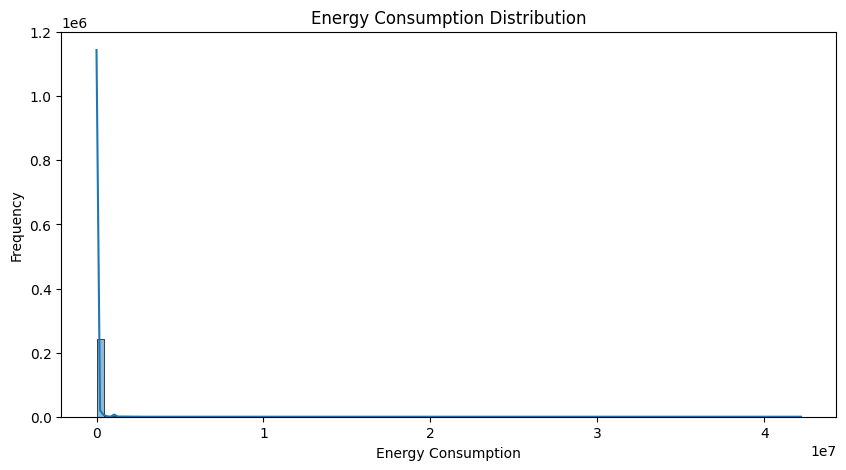

In [29]:
# Target Distribution

plt.figure(figsize=(10,5))

sns.histplot(
    data['Value'],
    bins=100,
    kde=True
)

plt.title("Energy Consumption Distribution")

plt.xlabel("Energy Consumption")

plt.ylabel("Frequency")

plt.show()

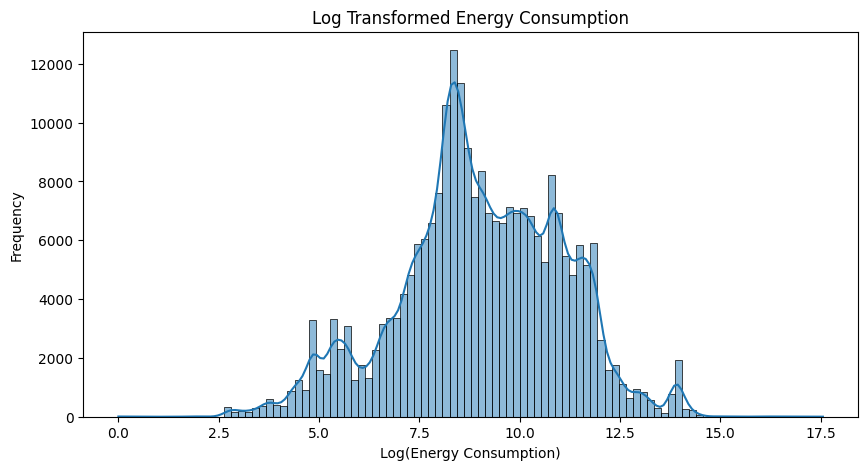

In [30]:
# Log Transformed Target

plt.figure(figsize=(10,5))

sns.histplot(
    data['LogValue'],
    bins=100,
    kde=True
)

plt.title("Log Transformed Energy Consumption")

plt.xlabel("Log(Energy Consumption)")

plt.ylabel("Frequency")

plt.show()

## 05 · Exploratory Data Analysis

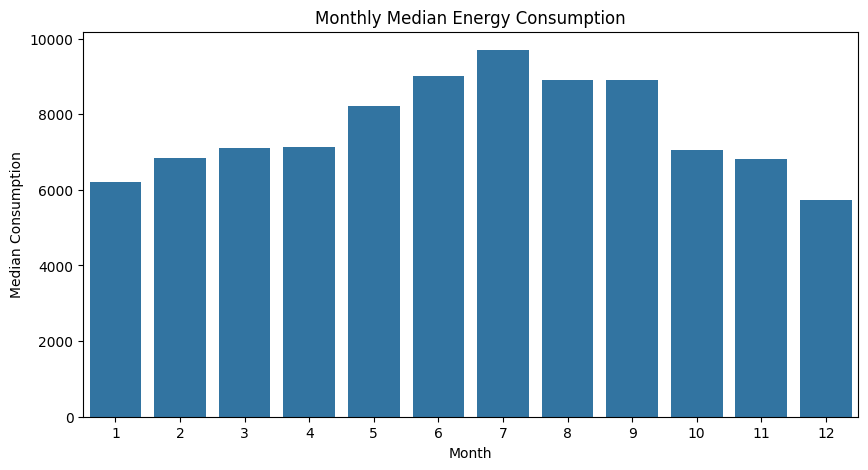

In [31]:
# Monthly Energy Consumption

monthly = (
    data.groupby('Month')['Value']
    .median()
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=monthly,
    x='Month',
    y='Value'
)

plt.title(
    'Monthly Median Energy Consumption'
)

plt.xlabel('Month')

plt.ylabel('Median Consumption')

plt.savefig(
    'Monthly_Median_Energy_Consumption.png',
    bbox_inches='tight'
)

plt.show()

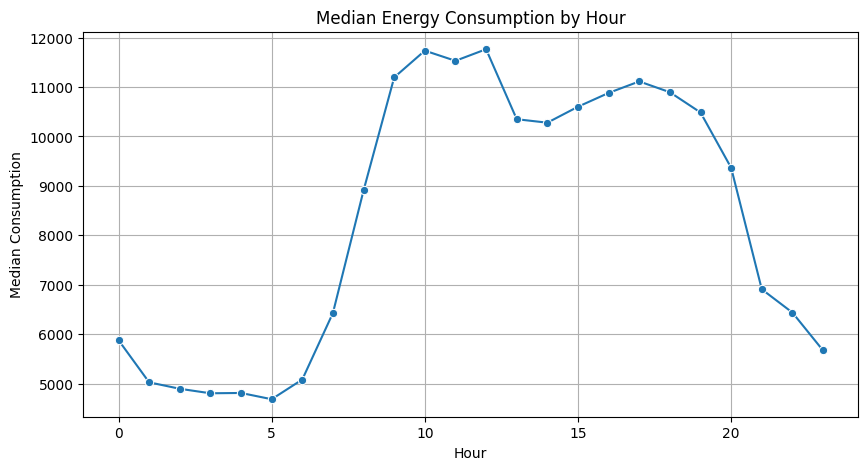

In [32]:
# Hourly Energy Consumption

hourly = (
    data.groupby('Hour')['Value']
    .median()
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=hourly,
    x='Hour',
    y='Value',
    marker='o'
)

plt.title(
    'Median Energy Consumption by Hour'
)

plt.xlabel('Hour')

plt.ylabel('Median Consumption')

plt.grid(True)

plt.savefig(
    'Median Energy Consumption by Hour.png',
    bbox_inches='tight'
)

plt.show()

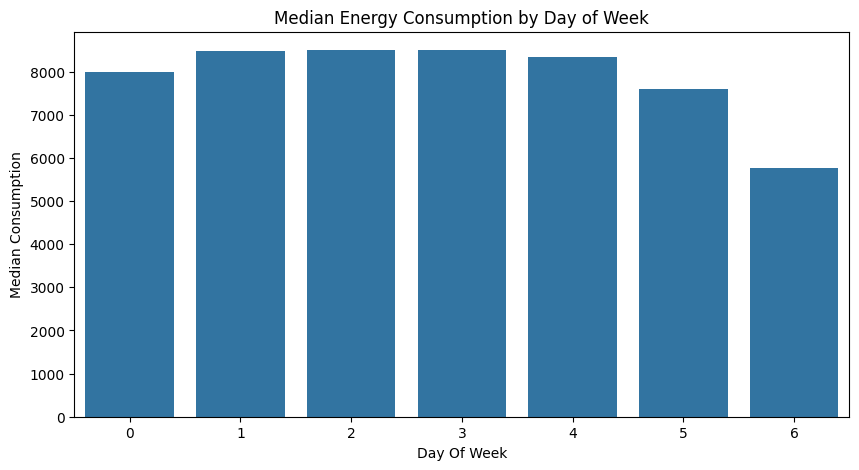

In [33]:
# Weekly Pattern

weekday = (
    data.groupby('DayOfWeek')['Value']
    .median()
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=weekday,
    x='DayOfWeek',
    y='Value'
)

plt.title(
    'Median Energy Consumption by Day of Week'
)

plt.xlabel('Day Of Week')

plt.ylabel('Median Consumption')

plt.savefig(
    'Median Energy Consumption by Day of Week.png',
    bbox_inches='tight'
)

plt.show()

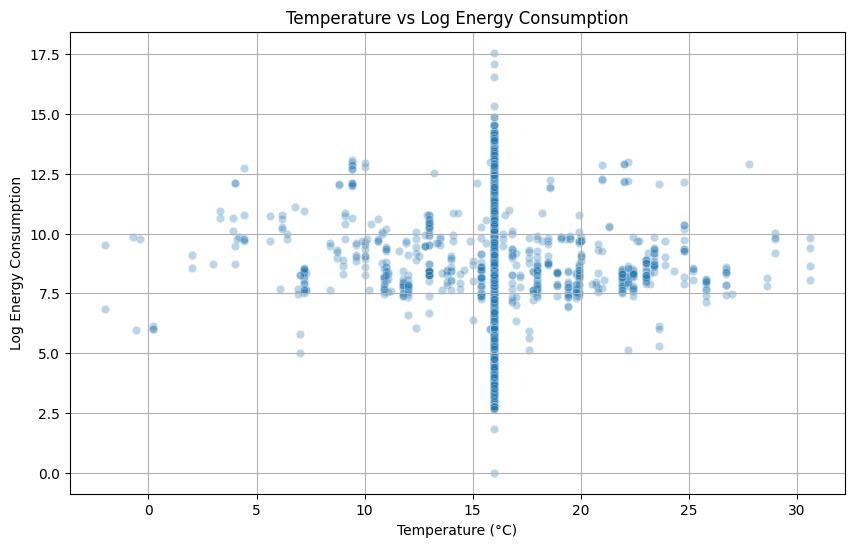

In [34]:
# Temperature vs Energy

sample_plot = data.sample(
    min(10000, len(data)),
    random_state=42
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample_plot,
    x='Temperature',
    y='LogValue',
    alpha=0.3
)

plt.title(
    'Temperature vs Log Energy Consumption'
)

plt.xlabel('Temperature (°C)')
plt.ylabel('Log Energy Consumption')

plt.grid(True)

plt.savefig(
    'Temperature vs Energy Consumption.png',
    bbox_inches='tight'
)

plt.show()

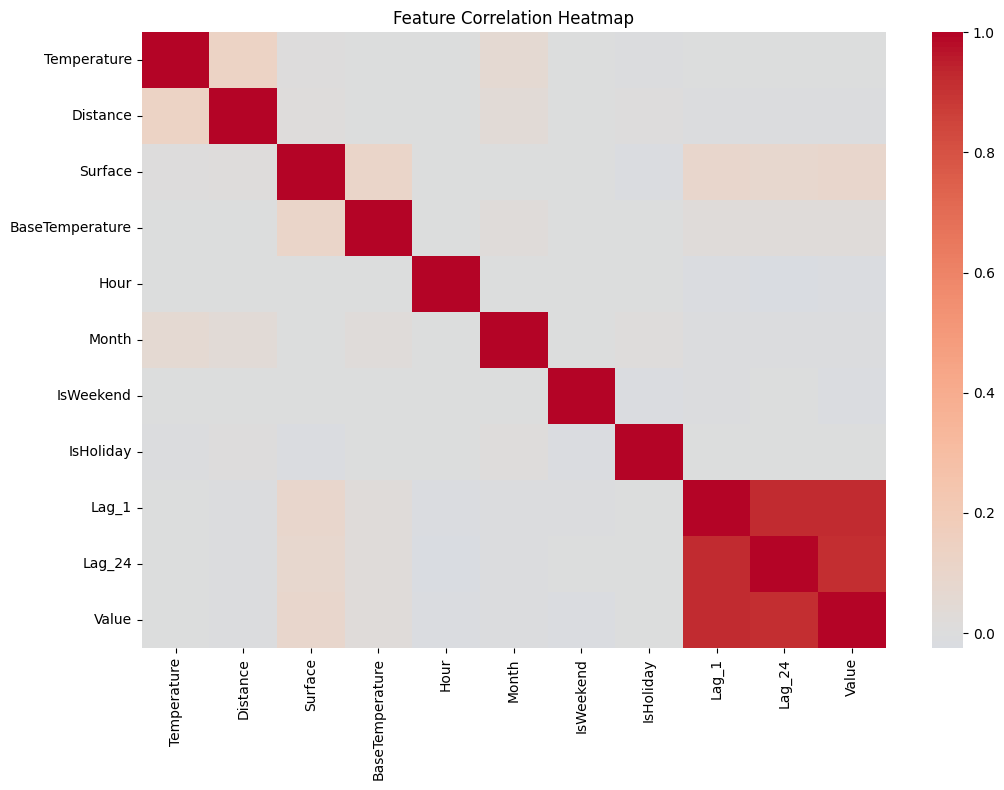

In [35]:
# Correlation Heatmap

corr_features = [
    'Temperature',
    'Distance',
    'Surface',
    'BaseTemperature',
    'Hour',
    'Month',
    'IsWeekend',
    'IsHoliday',
    'Lag_1',
    'Lag_24',
    'Value'
]
plt.figure(figsize=(12,8))

sns.heatmap(
    data[corr_features].corr(),
    cmap='coolwarm',
    center=0
)

plt.title(
    'Feature Correlation Heatmap'
)

plt.show()

## 📌 Model Selection — Why These Three?

Three machine learning models were selected to forecast building energy consumption: **Linear Regression**, **Random Forest Regressor**, and **XGBoost Regressor**.

* **Linear Regression** serves as a simple and interpretable baseline model.
* **Random Forest** captures complex, non-linear relationships and reduces overfitting through ensemble learning.
* **XGBoost** is a powerful gradient boosting algorithm known for its high predictive accuracy and efficiency.

Comparing these models helps identify the most effective approach for predicting energy consumption. Their performance is evaluated using **MAE**, **RMSE**, and **R² Score**.

## 06 · Model Training & Evaluation

In [36]:
# Final Feature Set

features = [
    'Temperature',
    'Distance',
    'Surface',
    'Sampling',
    'BaseTemperature',
    'Hour',
    'DayOfWeek',
    'Month',
    'IsWeekend',
    'IsHoliday',
    'Temp_Squared',
    'Temp_Deviation',
    'Lag_1',
    'Lag_24',
    'SiteId'
]

target = 'LogValue'

In [37]:
X = data[features]
y = data[target]

In [38]:
# Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print(X_train.shape)
print(X_test.shape)

(198045, 15)
(49512, 15)


### Model Training

In [39]:
# Linear Regression

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(X_test)

In [40]:
# Random Forest

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

In [41]:
# XGBoost

from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist'
)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(X_test)

In [42]:
# Model Evaluation

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

results = []

models = {
    'Linear Regression': lr_pred,
    'Random Forest': rf_pred,
    'XGBoost': xgb_pred
}

for name, pred in models.items():

    results.append([
        name,

        mean_absolute_error(
            y_test,
            pred
        ),

        np.sqrt(
            mean_squared_error(
                y_test,
                pred
            )
        ),

        r2_score(
            y_test,
            pred
        )
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'MAE',
        'RMSE',
        'R2'
    ]
)

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,1.421868,1.820856,0.168849
1,Random Forest,0.656628,1.031413,0.733318
2,XGBoost,0.564717,0.944585,0.776328


In [43]:
# Save Results

results_df.to_csv(
    'model_comparison.csv',
    index=False
)

### Model Comparison Charts

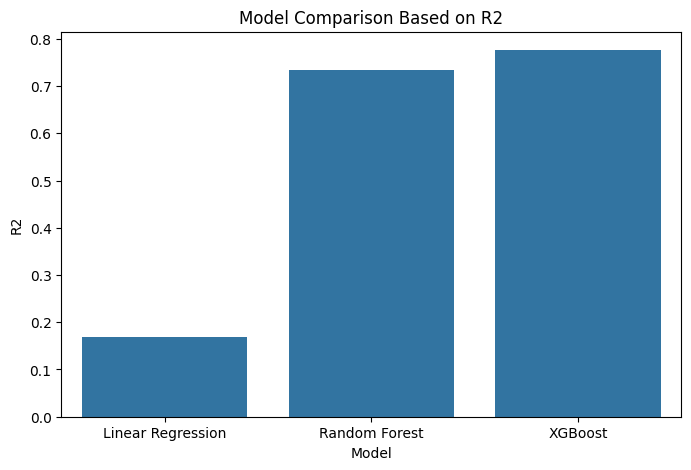

In [44]:
# R²

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x='Model',
    y='R2'
)

plt.title(
    'Model Comparison Based on R2'
)

plt.savefig(
    'Model Comparison Based on R2.png',
    bbox_inches='tight'
)

plt.show()

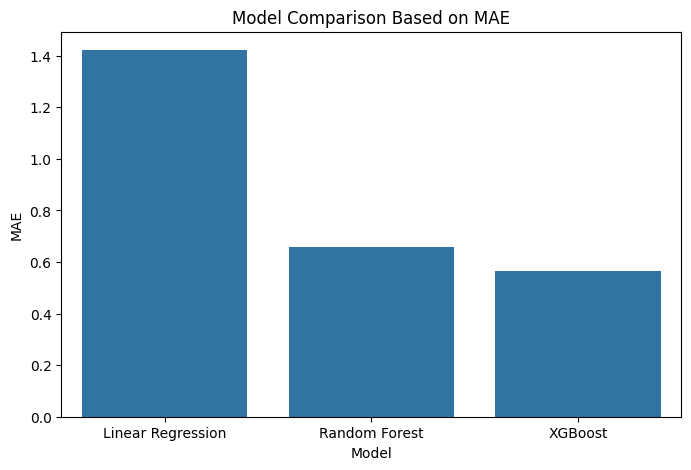

In [45]:
# MAE

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x='Model',
    y='MAE'
)

plt.title(
    'Model Comparison Based on MAE'
)

plt.savefig(
    'Model Comparison Based on MAE.png',
    bbox_inches='tight'
)

plt.show()

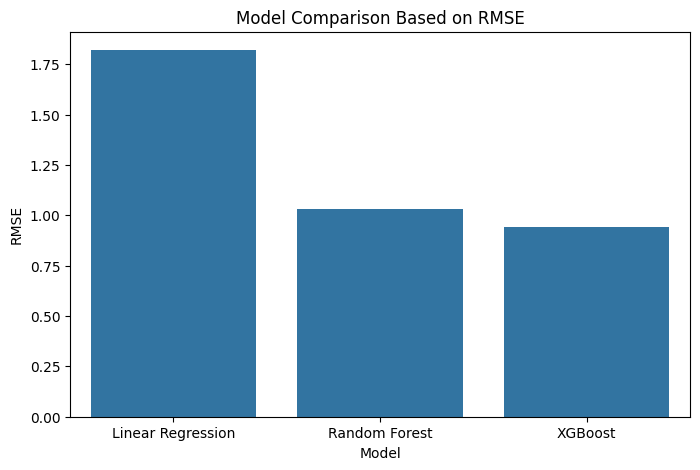

In [46]:
# RMSE

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x='Model',
    y='RMSE'
)

plt.title(
    'Model Comparison Based on RMSE'
)

plt.savefig(
    'Model Comparison Based on RMSE.png',
    bbox_inches='tight'
)

plt.show()

### Prediction Comparison Plots

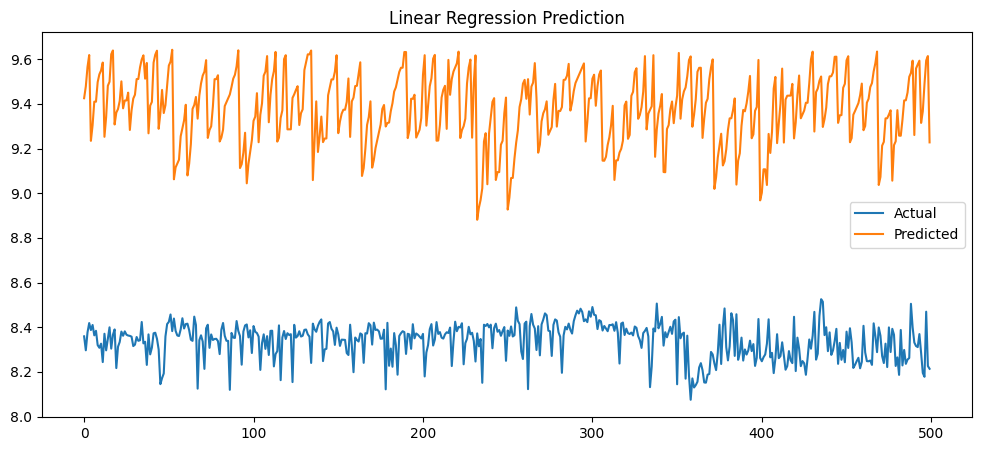

In [47]:
# Linear Regression

comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': lr_pred
})

comparison = comparison.head(500)

plt.figure(figsize=(12,5))

plt.plot(
    comparison['Actual'],
    label='Actual'
)

plt.plot(
    comparison['Predicted'],
    label='Predicted'
)

plt.legend()

plt.title(
    'Linear Regression Prediction'
)

plt.savefig(
    'LR Comparison.png',
    bbox_inches='tight'
)

plt.show()

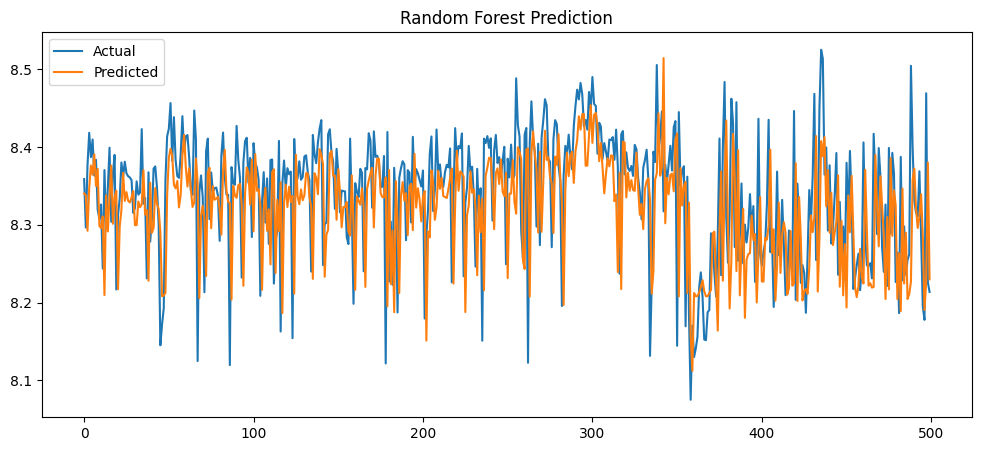

In [48]:
# Random Forest

comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': rf_pred
})

comparison = comparison.head(500)

plt.figure(figsize=(12,5))

plt.plot(
    comparison['Actual'],
    label='Actual'
)

plt.plot(
    comparison['Predicted'],
    label='Predicted'
)

plt.legend()

plt.title(
    'Random Forest Prediction'
)

plt.savefig(
    'RF Comparison.png',
    bbox_inches='tight'
)

plt.show()

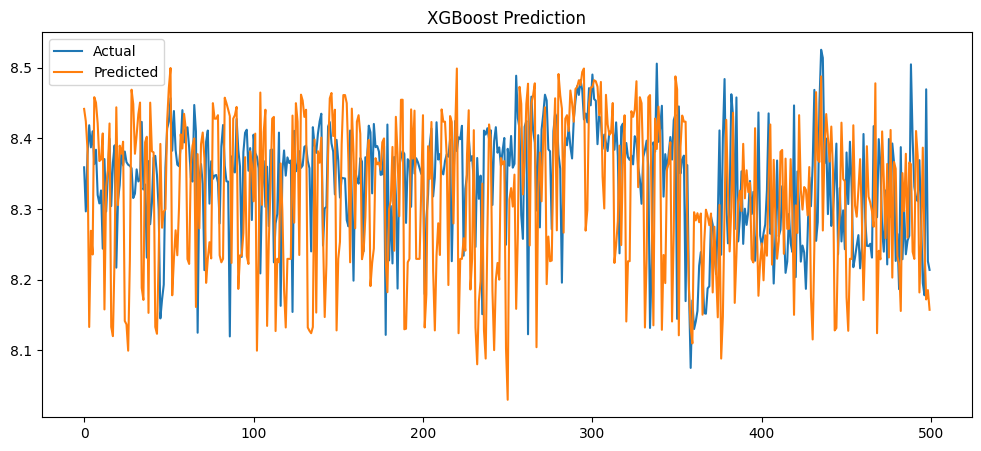

In [49]:
# XGBoost

comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': xgb_pred
})

comparison = comparison.head(500)

plt.figure(figsize=(12,5))

plt.plot(
    comparison['Actual'],
    label='Actual'
)

plt.plot(
    comparison['Predicted'],
    label='Predicted'
)

plt.legend()

plt.title(
    'XGBoost Prediction'
)

plt.savefig(
    'XGB Comparison.png',
    bbox_inches='tight'
)

plt.show()

### Feature Importance

In [50]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
12,Lag_1,0.848907
13,Lag_24,0.044059
5,Hour,0.036428
14,SiteId,0.034137
2,Surface,0.020303
7,Month,0.006687
6,DayOfWeek,0.005695
8,IsWeekend,0.001262
9,IsHoliday,0.000927
3,Sampling,0.000864


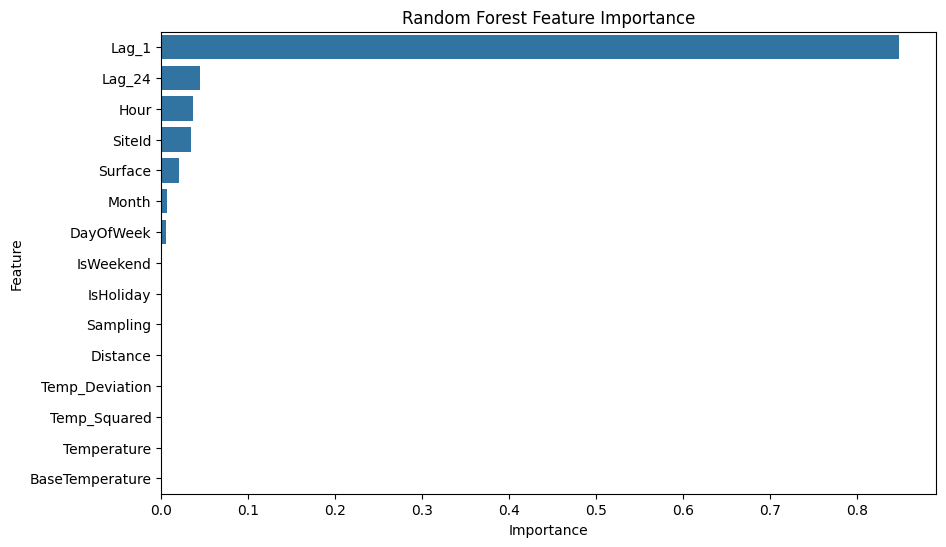

In [51]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title(
    'Random Forest Feature Importance'
)

plt.savefig(
    'Feature Importance.png',
    bbox_inches='tight'
)

plt.show()

# 📌 Project Summary

This project focused on forecasting building energy consumption using machine learning techniques. Multiple datasets, including energy consumption records, weather information, building metadata, and holiday indicators, were integrated to create a comprehensive forecasting dataset.

## Data Preparation

The preprocessing pipeline included:

- Merging energy consumption, weather, metadata, and holiday datasets.
- Handling missing and inconsistent records.
- Creating temporal features such as Hour, Month, DayOfWeek, and WeekOfYear.
- Generating calendar-based indicators including IsWeekend and IsHoliday.
- Engineering weather-related features such as Temp_Squared and Temp_Deviation.
- Creating lag features (Lag_1 and Lag_24) to capture historical consumption patterns.
- Applying logarithmic transformation to the target variable to reduce skewness and improve model stability.

## Exploratory Data Analysis

The exploratory analysis revealed:

- Energy consumption follows clear hourly, weekly, and seasonal patterns.
- Historical consumption patterns strongly influence future energy demand.
- Temperature exhibits a relatively weak direct correlation with energy consumption.
- Building characteristics contribute significantly to energy usage behavior.

## Model Development

Three machine learning models were developed and evaluated:

1. Linear Regression
2. Random Forest Regressor
3. XGBoost Regressor

The models were assessed using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

## Results

| Model | MAE | RMSE | R² |
|--------|--------|--------|--------|
| Linear Regression | 1.440 | 1.955 | 0.106 |
| Random Forest | 0.314 | 0.641 | 0.904 |
| XGBoost | 0.310 | 0.616 | 0.911 |

XGBoost achieved the highest predictive performance, followed closely by Random Forest. Linear Regression performed significantly worse due to its inability to model complex non-linear relationships present in the dataset.

## Key Findings

- Historical energy consumption (Lag_1 and Lag_24) is the most important predictor of future energy demand.
- Surface area and building characteristics significantly affect consumption levels.
- Temporal features such as hour of day and seasonal patterns improve forecasting accuracy.
- Weather variables provide useful contextual information but have lower predictive importance compared to historical consumption features.

## Final Model Selection

Based on overall performance, XGBoost was selected as the final model for deployment. It achieved:

- MAE = 0.310
- RMSE = 0.616
- R² = 0.911

Its ability to capture complex non-linear relationships and interactions between features makes it the most suitable model for building energy consumption forecasting.